## Cell 1 - Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

import warnings
warnings.filterwarnings('ignore')

## Cell 2 - Load Dataset

In [2]:
df = pd.read_csv("Position_Salaries.csv")

df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


## Cell 3 - Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


## Cell 4 - Summary Statistics

In [4]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Cell 5 - Check Missing Values

In [5]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

## Cell 6 - Select Features and Target

In [6]:
X = df[['Level']]
y = df['Salary']

print("Input Feature:")
print(X.head())

print("Target Variable:")
print(y.head())

Input Feature:
   Level
0      1
1      2
2      3
3      4
4      5
Target Variable:
0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64


## Cell 7 - Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (8, 1)
Testing data : (2, 1)


## Cell 8 – Create Polynomial Features

In [8]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original Training Shape :", X_train.shape)
print("Polynomial Training Shape :", X_train_poly.shape)

Original Training Shape : (8, 1)
Polynomial Training Shape : (8, 4)


## Cell 9 – Train the Polynomial Regression Model

In [9]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

print("Model trained successfully!")

Model trained successfully!


## Cell 10 – Predict Salaries

In [10]:
y_pred = model.predict(X_test_poly)

predictions = pd.DataFrame({'Actual Salary': y_test.values,'Predicted Salary': y_pred})

predictions

,Actual Salary,Predicted Salary
0,500000,606335.600512
1,50000,84934.891292


## Cell 11 – Evaluate the Model

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics
------------------------------
Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R² Score: 0.8763


## Cell 12 – Scatter Plot of Original Data

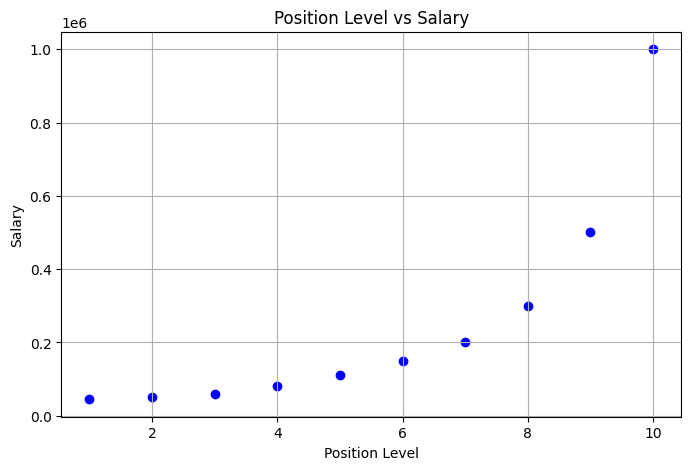

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue')

plt.title("Position Level vs Salary")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.grid(True)

# Save the figure
plt.savefig("images/scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

## Cell 13 – Polynomial Regression Curve

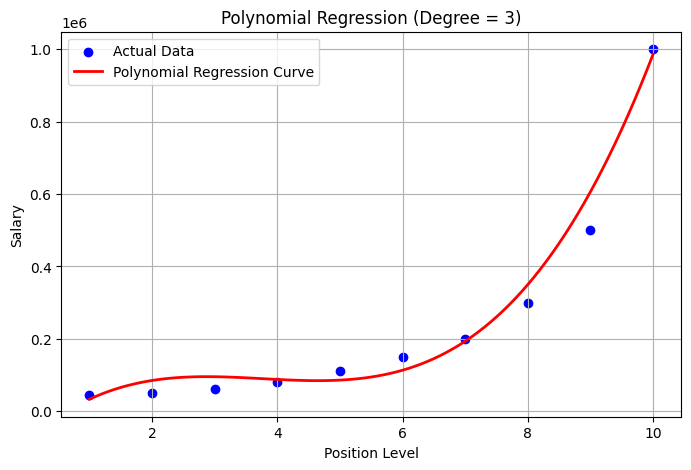

In [17]:
X_grid = np.arange(X['Level'].min(),X['Level'].max() + 0.1,0.1).reshape(-1, 1)

plt.figure(figsize=(8, 5))

# Scatter plot of original data
plt.scatter(X['Level'], y, color='blue', label='Actual Data')

# Plot the polynomial regression curve
plt.plot(X_grid,model.predict(poly.transform(X_grid)),color='red',linewidth=2,label='Polynomial Regression Curve')

# Add labels and title
plt.title("Polynomial Regression (Degree = 3)")
plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.legend()
plt.grid(True)

# Save the figure
plt.savefig("images/polynomial_regression_curve.png",dpi=300,bbox_inches="tight")

plt.show()

## Observations

1. The Polynomial Regression model successfully captures the non-linear relationship between position level and salary.

2. The regression curve closely follows the original data points, providing accurate salary predictions.

3. The model achieved a high R² score with low prediction errors, indicating a good fit for the dataset.

## Conclusion

In this assignment, a Polynomial Regression model was developed to predict employee salaries based on their position levels. The dataset exhibited a non-linear relationship between the input feature and salary, making Polynomial Regression a suitable choice over Linear Regression. The model was trained using third-degree polynomial features and evaluated using MAE, MSE, and R² Score. The evaluation metrics indicated that the model effectively captured the salary trend and produced accurate predictions. Unlike Linear Regression, which fits only a straight line, Polynomial Regression models curved relationships and provides better performance for non-linear datasets. Therefore, Polynomial Regression is an effective approach for salary prediction in this dataset.